# Урок 03. Собственные числа и SVD

> **Зачем это нужно:** PCA, спектральная кластеризация, рекомендательные системы, latent semantic analysis — всё это про разложение матриц на компоненты. SVD — самая полезная операция в прикладной линейной алгебре.

---

### Что такое собственные векторы и числа?

**Собственные векторы и собственные числа** — это важнейшие понятия линейной алгебры, которые описывают, как квадратная матрица (линейное преобразование) воздействует на определенные направления в пространстве. 

Если говорить просто, при умножении матрицы на свой собственный вектор он **не меняет своего направления**, а только растягивается или сжимается в число раз, равное собственному числу.

---

### Геометрический смысл

Обычно, когда матрица действует на вектор, она поворачивает его и меняет его длину. Однако для каждой матрицы существуют особые направления:
* **Собственный вектор** ($\vec{v}$) — это ненулевой вектор, направление которого сохраняется (или меняется на строго противоположное) после преобразования.
* **Собственное число** ($\lambda$) — это коэффициент, который показывает, во сколько раз растянулся, сжался или развернулся вектор.
  * Если $\lambda > 1$ — вектор удлиняется.
  * Если $0 < \lambda < 1$ — вектор укорачивается.
  * Если $\lambda < 0$ — вектор разворачивается в противоположную сторону.

---

### Математическое определение

Пусть $A$ — квадратная матрица размера $n \times n$. Ненулевой вектор $\vec{v}$ называется **собственным вектором** матрицы $A$, а скаляр $\lambda$ — ее **собственным числом**, если выполняется уравнение:

$$A \vec{v} = \lambda \vec{v}$$

Где:
* $A$ — матрица преобразования.
* $\vec{v}$ — собственный вектор ($\vec{v} \neq \vec{0}$).
* $\lambda$ — собственное число.

---

### Алгоритм нахождения

Чтобы найти собственные значения и векторы, уравнение $A \vec{v} = \lambda \vec{v}$ переписывают в виде однородной системы уравнений:

$$(A - \lambda I)\vec{v} = \vec{0}$$

Здесь $I$ — единичная матрица той же размерности, что и $A$. Так как по определению $\vec{v} \neq \vec{0}$, данная система имеет ненулевые решения только тогда, когда матрица $(A - \lambda I)$ вырождена.

Процесс вычисления состоит из двух шагов:

1. **Нахождение собственных чисел**: 
   Решают характеристическое уравнение (определитель равен нулю, чтобы матрица была вырожденной, нельзя было найти обратную матрицу. Если матрицы в скобках будет иметь обратную матрицу, то мы сможем домножить на нее слева с двух сторон. Если мы сможем домножить, то справа будет нулевой вектор, а значит вектор v будет нулевым, чего быть не может по определению):
   $$\det(A - \lambda I) = 0$$
   Корни полученного многочлена и будут являться собственными числами $\lambda$.

2. **Нахождение собственных векторов**: 
   Для каждого найденного значения $\lambda$ подставляют его в систему $(A - \lambda I)\vec{v} = \vec{0}$ и находят фундаментальную систему решений (векторы $\vec{v}$).

---

### Сферы применения

* **Data Science (Метод главных компонент / PCA)**: для снижения размерности признаков с сохранением максимума дисперсии данных.
* **Поисковые системы (Google PageRank)**: собственное число матрицы переходов определяет авторитетность веб-страниц.
* **Компьютерная графика**: для анализа деформаций, масштабирования и поворота трехмерных объектов.
* **Физика и механика**: для расчета резонансных частот конструкций и в квантовой механике (уравнение Шрёдингера).


## Применение собственных векторов в продвинутых алгоритмах Machine Learning

В анализе данных и машинном обучении собственные векторы выполняют одну главную задачу: **они находят скрытые (латентные) оси максимальной информации, связей или схожести**, позволяя сжать терабайты данных до нескольких важнейших признаков.

---

### 1. Метод главных компонент (PCA — Principal Component Analysis)

* **Что это такое:** Метод линейного снижения размерности данных. Представьте облако точек в 3D-пространстве; PCA проецирует их на 2D-плоскость так, чтобы точки как можно меньше «слиплись» и сохранили максимум исходного разброса (дисперсии).
* **Связь с собственными векторами:** 
  1. На основе исходных данных строится **матрица ковариации** (матрица связей между признаками).
  2. Из этой матрицы извлекаются собственные векторы и числа.
  3. **Собственные векторы** задают новые направления осей (те самые *Главные компоненты*), вдоль которых данные имеют наибольший разброс.
  4. **Собственные числа** ($\lambda$) показывают величину дисперсии вдоль этих осей. Мы сортируем их по убыванию и оставляем только топ-векторы с самыми большими $\lambda$, отбрасывая шум.

---

### 2. Спектральная кластеризация (Spectral Clustering)

* **Что это такое:** Алгоритм кластеризации, способный разделять сложные структуры данных, которые «вложены» друг в друга (например, круги на воде или спирали), где классический $k$-means бессилен.
* **Связь с собственными векторами:** 
  1. Данные представляются в виде графа, где точки — это вершины, а веса ребер — степень их сходства. 
  2. Для этого графа строится специальная матрица — **Лапласиан графа** ($L = D - W$, где $D$ — матрица степеней, $W$ — матрица смежности).
  3. Находятся собственные векторы матрицы $L$. 
  4. **Собственные векторы, соответствующие *наименьшим* ненулевым собственным числам** (особенно вектор Фидлера), содержат информацию о том, как оптимально «разрезать» граф на изолированные сообщества с минимальными потерями связей. Эти векторы сжимают сложную геометрию в простое пространство, где уже легко работает обычный $k$-means.

---

### 3. Рекомендательные системы (Коллаборативная фильтрация через SVD)

* **Что это такое:** Алгоритмы, предсказывающие, какой товар/фильм понравится пользователю, на основе оценок похожих пользователей. Яркий пример — алгоритм *SVD (Singular Value Decomposition)*, который прославился на конкурсе Netflix Prize.
* **Связь с собственными векторами:**
  1. Строится огромная разреженная матрица $R$ (строки — пользователи, столбцы — фильмы, в ячейках — оценки).
  2. SVD раскладывает её на произведение матриц, выделяя скрытые факторы (например, жанр фильма или настроение пользователя).
  3. Математически SVD напрямую связано с собственными векторами: левые сингулярные векторы матрицы $R$ — это **собственные векторы матрицы $R R^T$** (описывают сходство пользователей), а правые сингулярные векторы — это **собственные векторы матрицы $R^T R$** (описывают сходство фильмов).

---

### 4. Латентно-семантический анализ (LSA — Latent Semantic Analysis)

* **Что это такое:** Метод обработки естественного языка (NLP), который позволяет находить скрытый смысл (темы) в текстах. Он понимает, что слова «синонимы» связаны по смыслу, даже если они пишутся по-разному.
* **Связь с собственными векторами:**
  1. Тексты переводятся в матрицу «Термины-Документы» (TF-IDF), где строки — слова, а столбцы — статьи/тексты.
  2. К этой матрице применяется усеченное SVD-разложение (аналогично рекомендательным системам).
  3. **Собственные векторы** в данном случае представляют собой **оси скрытых тематик** (контекстов). Проекция слова на такой вектор показывает, к какой теме («Спорт», «Политика», «IT») это слово относится. Это позволяет сравнивать документы не по буквальному совпадению слов, а по близости их скрытого смысла.

---

### Резюме: Что объединяет все эти методы?

Во всех четырех алгоритмах работает концепция **низкоранговой аппроксимации**. Матрицы реальных данных избыточны и зашумлены. Поиск собственных векторов позволяет отбросить направления, вдоль которых ничего не происходит (маленькие $\lambda$), и оставить только базис («каркас»), на котором держатся все скрытые закономерности данных.


## 1. Собственные числа и векторы

In [1]:
import numpy as np

A = np.array([[2, 0], [0, 3]])
eigvals, eigvecs = np.linalg.eig(A)
print(eigvals)
print(eigvecs)

print(eigvals.real)
print(eigvecs.real)


[2.+0.j 3.+0.j]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
[2. 3.]
[[1. 0.]
 [0. 1.]]


### Интуиция: Разбор "взрыва" и "затухания" через собственные числа

Давайте разберем эту фразу по шагам. Она описывает базовый математический закон: **многократное умножение на одну и ту же матрицу работает как геометрическая прогрессия (степень)**.

---

### 1. Что значит "применять $A$ много раз подряд"?

Применить матрицу к вектору — значит умножить её на этот вектор: $A\vec{v}$.
Применить её 3 раза подряд — это:
$$A \cdot A \cdot A \cdot \vec{v} = A^3 \vec{v}$$

Вспомним определение собственного вектора: $A\vec{v} = \lambda\vec{v}$. Матрица просто умножает вектор на число $\lambda$.
Если мы применим матрицу $A$ к её собственному вектору $n$ раз, произойдет следующее:
* 1 раз: $A\vec{v} = \lambda\vec{v}$
* 2 раза: $A(A\vec{v}) = A(\lambda\vec{v}) = \lambda(A\vec{v}) = \lambda(\lambda\vec{v}) = \lambda^2\vec{v}$
* $n$ раз: $A^n\vec{v} = \lambda^n\vec{v}$

**Вывод:** Многократное умножение на матрицу возводит её собственные числа в степень $n$.

---

### 2. Что значит "длинное направление вытянется ещё сильнее"?

Любой случайный вектор в пространстве можно составить из суммы собственных векторов матрицы. 
Представьте матрицу, у которой два собственных числа:
* $\lambda_1 = 2$ (растягивает вектор в 2 раза) — *"длинное направление"*
* $\lambda_2 = 0.5$ (сжимает вектор в 2 раза) — *"короткое направление"*

Если мы умножим матрицу саму на себя 10 раз ($A^{10}$):
* Первое направление изменится в $\lambda_1^{10} = 2^{10} = 1024$ раза! (Оно чудовищно **вытянется**)
* Второе направление изменится в $\lambda_2^{10} = 0.5^{10} \approx 0.00097$ раза. (Оно практически **исчезнет**)

Даже если изначально направления были примерно равны, через несколько шагов **первое ("длинное") направление полностью доминирует**, а остальные затухают.

---

### 3. Как это связано с RNN и градиентами?

Рекуррентные нейронные сети (RNN) обрабатывают последовательности (например, текст из 50 слов). Чтобы передавать информацию от 1-го слова к 50-му, RNN на каждом шаге использует **одну и ту же матрицу весов** $W$.

Когда мы считаем градиенты (производные) для обучения сети на длинной последовательности, включается *производная сложной функции* (Chain Rule). Математически это превращается в умножение матрицы весов $W$ самой на себя много раз подряд ($W \cdot W \cdot W...$).

И вот тут стреляет наше правило степеней ($\lambda^n$):
1. **Взрыв градиентов (Exploding Gradients):** Если у матрицы весов $W$ хотя бы одно собственное число **чуть больше единицы** (например, $\lambda = 1.1$), то на 100-м шаге оно превратится в $1.1^{100} \approx 13780$. Градиенты станут огромными, веса сети сломаются, алгоритм выдаст ошибки `NaN`.
2. **Затухание градиентов (Vanishing Gradients):** Если все собственные числа матрицы $W$ **меньше единицы** (например, $\lambda = 0.9$), то на 100-м шаге мы получим $0.9^{100} \approx 0.00002$. Градиент станет почти нулевым. Сеть "забудет" начало текста и ничему не научится.

---

### 🛠 Как с этим борются в Deep Learning?
* Чтобы градиенты не взрывали сеть, применяют **Gradient Clipping** (принудительно обрезают слишком большие значения).
* Чтобы градиенты не затухали, вместо обычных RNN используют архитектуры **LSTM** и **GRU**. В них встроены специальные "ворота" (gates), которые заменяют опасное умножение матриц на безопасное поэлементное сложение.


---

## 2. Спектральное разложение вещественной симметричной матрицы

Для симметричной матрицы существует разложение:

$$ A = Q \Lambda Q^T $$

где `Q` — ортогональная матрица собственных векторов, `Λ` — диагональ из собственных чисел.

In [2]:
A = np.array([[4, 1], [1, 3]]) 
eigvals, Q = np.linalg.eigh(A)
lambda_matrix = np.diag(eigvals)
reconstructed = Q @ lambda_matrix @ Q.T
print(np.allclose(A, reconstructed))

#eigh - Буква h в названии означает Hermitian 
# (эрмитова матрица — комплексный аналог 
# вещественной симметричной матрицы).

True


## 3. SVD

Сингулярное разложение работает для **любой** матрицы (не обязательно квадратной):

$$ A = U \Sigma V^T $$

- `U` — ортогональная (m × m), левые сингулярные векторы.
- `Σ` — диагональная (m × n) с неотрицательными числами по убыванию — сингулярные значения.
- `V^T` — ортогональная (n × n), правые сингулярные векторы.
---

### Спектральное разложение (Eigendecomposition) vs Сингулярное разложение (SVD)

**Спектральное разложение** и **сингулярное разложение (SVD — Singular Value Decomposition)** — это два фундаментальных метода распада матрицы на произведение более простых матриц. 

Главное отличие между ними заключается в **типе матриц**, к которым они применимы, и в геометрических свойствах получаемых векторов.

---

### 1. Сравнительный анализ

* **Применимость к матрицам:**
  * **Спектральное:** Работает **только для квадратных** матриц ($n \times n$). При этом матрица должна иметь полный набор линейно независимых собственных векторов (быть диагонализируемой).
  * **Сингулярное (SVD):** Работает **абсолютно для любых** матриц — прямоугольных ($m \times n$), квадратных, вырожденных или нулевых. Ограничений нет.

* **Математическая формула:**
  * **Спектральное:** $A = Q \Lambda Q^{-1}$ 
    *(где $Q$ — матрица собственных векторов, $\Lambda$ — диагональная матрица с собственными числами $\lambda$)*.
  * **Сингулярное:** $A = U \Sigma V^T$
    *(где $U$ и $V$ — ортогональные матрицы левых и правых сингулярных векторов, а $\Sigma$ — диагональная матрица с сингулярными числами $\sigma$)*.

* **Свойства векторов:**
  * **Спектральное:** Векторы в матрице $Q$ (собственные векторы) не обязательно перпендикулярны друг другу. Они гарантированно ортогональны только в том случае, если исходная матрица $A$ — симметричная.
  * **Сингулярное:** Векторы в матрицах $U$ и $V$ **всегда строго перпендикулярны** друг другу (образуют идеальный ортонормированный базис) для абсолютно любой исходной матрицы.

* **Природа чисел ($\lambda$ и $\sigma$):**
  * **Спектральное:** Собственные числа $\lambda$ могут быть отрицательными или комплексными (содержать мнимую единицу $j$).
  * **Сингулярное:** Сингулярные числа $\sigma$ **всегда вещественные и неотрицательные** ($\sigma \ge 0$). Они всегда отсортированы в матрице $\Sigma$ строго по убыванию.

---

### Геометрический смысл «на пальцах»

Представьте, что матрица — это геометрическое преобразование пространства (сжатие, растяжение или поворот векторов):

* **Спектральное разложение** ищет такие направления, которые при трансформации матрицей **не меняют своей линии движения** (не поворачиваются), а только масштабируются. Мы смотрим на матрицу «изнутри» её собственных силовых осей.
* **Сингулярное разложение** работает иначе. Оно берет идеальную единичную сферу (круг в 2D), трансформирует её матрицей $A$ в эллипсоид (овал) и смотрит на оси этого получившегося овала. Направление главных осей овала — это векторы $U$, длина этих осей — сингулярные числа $\sigma$, а векторы исходной сферы, которые превратились в эти оси — это векторы $V$.

---

### Математическая связь между методами

Сингулярное разложение прямоугольной матрицы $A$ напрямую связано со спектральным разложением симметричных квадратных матриц, построенных на её основе:

1. Собственные векторы матрицы $A A^T$ в точности равны **левым сингулярным векторам ($U$)** матрицы $A$.
2. Собственные векторы матрицы $A^T A$ в точности равны **правым сингулярным векторам ($V$)** матрицы $A$.
3. Собственные числа ($\lambda$) этих квадратных матриц равны квадратам сингулярных чисел исходной матрицы: $\lambda = \sigma^2$.

---

### Области применения

* **Спектральное разложение** используют там, где система эволюционирует во времени с одной и той же структурой: марковские цепи, возведение матрицы весов в степень в RNN, анализ графов через Лапласиан в спектральной кластеризации.
* **Сингулярное разложение (SVD)** используют, когда данные представляют собой прямоугольные таблицы «объекты-признаки» или «пользователи-фильмы»: рекомендательные системы (SVD-алгоритмы), PCA, LSA-анализ текстов, сжатие изображений.


---
# Математическая структура SVD (Сингулярного разложения)

Сингулярное разложение (**SVD** — *Singular Value Decomposition*) раскладывает **любую** прямоугольную матрицу данных $X$ размера $(m \times n)$ на три специальные матрицы:

$$X = U \cdot \Sigma \cdot V^T$$

---

## Что означает каждая буква в разложении:

### 1. Матрица $U$ (Левые сингулярные векторы)
* **Размерность:** $(m \times m)$ или $(m \times n)$ в усеченном виде (`full_matrices=False`).
* **Свойства:** Столбцы этой матрицы ортогональны (перпендикулярны друг другу) и имеют единичную длину. Геометрически умножение на $U$ работает как чистый поворот пространства без искажения масштаба.
* **Смысл:** Столбцы $U$ — это собственные векторы матрицы $X X^T$. В задаче с лицами строки матрицы $U$ показывают, как конкретные люди (объекты) соотносятся с новыми базовыми признаками.

### 2. Матрица $\Sigma$ (в коде NumPy: вектор `S`)
* **Размерность:** Математически это прямоугольная матрица $(m \times n)$, но NumPy возвращает её в виде компактного **одномерного вектора** длины $\min(m, n)$.
* **Свойства:** Содержит вещественные неотрицательные числа (сингулярные числа), которые строго отсортированы **по убыванию**: $\sigma_1 \ge \sigma_2 \ge \sigma_3 \dots \ge 0$.
* **Смысл:** Это коэффициенты растяжения. Они отражают **силу (важность)** каждой соответствующей оси. Чем больше сингулярное число, тем больше важной информации (дисперсии) скрыто за этой компонентой. Близкие к нулю значения — это цифровой шум, который можно безболезненно выкинуть при сжатии.

### 3. Матрица $V^T$ (в коде NumPy: матрица `Vt`)
* **Размерность:** Квадратная матрица $(n \times n)$, где $n$ — количество исходных признаков.
* **Свойства:** Является ортогональной матрицей для пространства признаков. Поскольку она записана в транспонированном виде ($V^T$), её геометрические оси лежат **в строках**, а не в столбцах.
* **Смысл:** Строки матрицы $V^T$ — это собственные векторы ковариационной матрицы $X^T X$. В контексте метода главных компонент (PCA) это и есть **направления главных компонент**. Именно первые $k$ строк этой матрицы (`Vt[:k]`) представляют собой «базовые шаблоны» (в нашей задаче — *Eigenfaces* / собственные лица).

---

## Геометрическая суть формулы

Формула $X = U \Sigma V^T$ утверждает, что любое сложное линейное преобразование данных $X$ можно разбить на три простых последовательных шага:
1. **$V^T$** — поворачивает исходную систему координат так, чтобы оси совпали с направлениями максимального разброса данных.
2. **$\Sigma$** — растягивает или сжимает данные вдоль этих новых осей (проявляя масштаб важности признаков).
3. **$U$** — снова поворачивает пространство, переводя результат в финальную систему координат объектов.


In [3]:
A = np.random.randn(5, 3)
U, S, Vt = np.linalg.svd(A, full_matrices=False)
print(U.shape, S.shape, Vt.shape)

A_back = U @ np.diag(S) @ Vt
print(np.allclose(A, A_back))

(5, 3) (3,) (3, 3)
True


**Интуиция:** любое линейное преобразование = поворот → растяжение по осям → ещё один поворот. `V^T` поворачивает, `Σ` растягивает, `U` поворачивает.

---

## 4. Низкоранговое приближение

Хотите сжать матрицу — оставьте только `k` самых больших сингулярных чисел. Это лучшее приближение ранга `k` (теорема Эккарта–Янга).

**Низкоранговое приближение** — это способ заменить исходную сложную матрицу более простой матрицей меньшего ранга $k$ с минимальной потерей информации. Метод лежит в основе сжатия данных, фильтрации шума и уменьшения размерности.

---

## 1. Математическая формулировка

Сингулярное разложение (SVD) позволяет представить любую матрицу $A$ как сумму внешних произведений векторов (матриц ранга 1):

$$A = \sum_{i=1}^{r} \sigma_i u_i v_i^T$$

Где:
*   $\sigma_i$ — сингулярные числа, строго отсортированные по убыванию ($\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r > 0$).
*   $u_i$ и $v_i$ — левые и правые сингулярные векторы.
*   $r$ — исходный ранг матрицы.

Чтобы получить **лучшее приближение ранга $k$** (обозначим его $A_k$), достаточно оборвать эту сумму на $k$-м шаге ($k < r$), приравняв все оставшиеся сингулярные числа к нулю:

$$A_k = \sum_{i=1}^{k} \sigma_i u_i v_i^T$$

---

## 2. Суть теоремы Эккарта — Янга

Теорема строго доказывает, что матрица $A_k$, полученная через SVD, является **наилучшим возможным приближением** исходной матрицы $A$ среди всех матриц ранга $k$. Она минимизирует ошибку одновременно в двух матричных нормах:

1. **Спектральная норма (ошибка по максимальному вектору):**
   $$\|A - A_k\|_2 = \sigma_{k+1}$$

2. **Норма Фробениуса (суммарная среднеквадратичная ошибка всех элементов):**
   $$\|A - A_k\|_F = \sqrt{\sigma_{k+1}^2 + \sigma_{k+2}^2 + \dots + \sigma_r^2}$$

> **Главный вывод:** Любая другая матрица ранга $k$, созданная любым другим способом, даст бóльшую ошибку приближения.

---

## 3. Геометрическая интуиция

Любое линейное преобразование переводит сферу из исходного пространства в **эллипсоид** в конечном пространстве.
*   Сингулярные числа $\sigma_i$ — это **длины полуосей** этого эллипсоида.
*   Первое число $\sigma_1$ задает самую длинную (главную) ось, вдоль которой данные растянуты сильнее всего.
*   Последующие числа задают все более короткие оси. Маленькие значения $\sigma_i$ на практических данных обычно отвечают за микроскопический случайный шум.

Когда мы оставляем только $k$ наибольших чисел, мы геометрически **сплющиваем (проецируем)** многомерный эллипсоид вдоль его самых коротких осей. Мы отсекаем малозначимые измерения, оставляя только каркас из самых широких и информативных направлений.

---

## 4. Практическое применение

*   **Сжатие изображений:** Изображение представляется в виде матрицы пикселей. Вместо хранения миллионов отдельных пикселей, SVD позволяет хранить только топ-$k$ векторов $u_i$ и $v_i$. Это существенно уменьшает вес файла при визуальном сохранении качества.
*   **Снижение шума (Denoising):** Мелкие сингулярные числа зануляют, предполагая, что в них содержится случайный шум, а полезный сигнал сосредоточен в первых (крупных) компонентах.
*   **Рекомендательные системы (Тематическое моделирование / Сжатие признаков):** Помогает находить скрытые взаимосвязи (например, неявные жанры в матрице «пользователи $\times$ фильмы»), сокращая размерность признакового пространства без потери контекста.


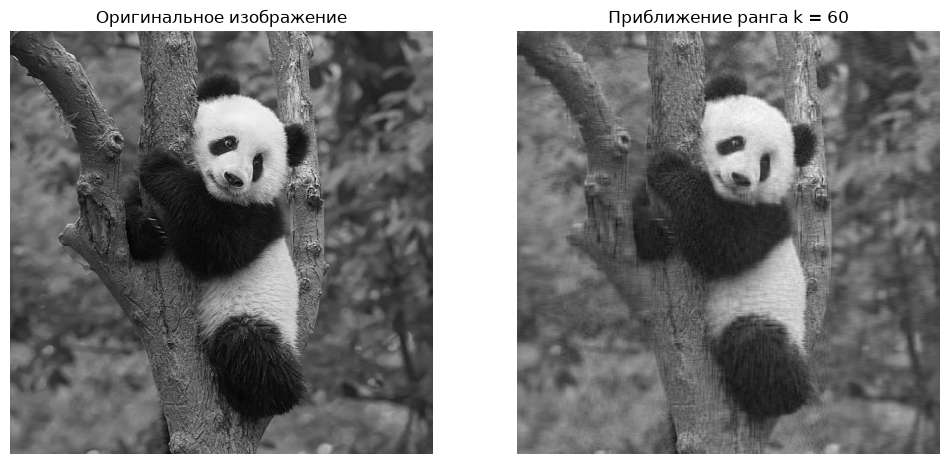

In [4]:
def low_rank(A, k):
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

# Сжатие изображения
from PIL import Image
img = np.array(Image.open("02-matrices-task3-1.jpg").convert("L"), dtype=float)
img_k = low_rank(img, k=60)




# Визаулизация изображений
from matplotlib import pyplot as plt

# Создаем окно для двух графиков
plt.figure(figsize=(12, 6))

# Левое окошко — оригинальное фото
plt.subplot(1, 2, 1)
plt.title("Оригинальное изображение")
plt.imshow(img, cmap='gray')
plt.axis('off') # Отключаем координатные оси

# Правое окошко — сжатое фото (ранг 60)
plt.subplot(1, 2, 2)
plt.title("Приближение ранга k = 60")
plt.imshow(img_k, cmap='gray')
plt.axis('off')

# Показываем результат на экране
plt.show()


.convert('L') — переводит картинку в оттенки серого (Luminance). Это необходимо, так как стандартное SVD работает с двумерными матрицами. Обычное цветное фото имеет 3 канала (RGB) и является трехмерным тензором, а черно-белое фото — это чистая матрица, где каждое число от 0 до 255 означает яркость пикселя.

np.array(..., dtype=float) — превращает картинку в массив NumPy и переводит целые числа в вещественные (float), так как математические операции SVD требуют высокой точности с плавающей точкой.

---
# Почему адаптация называется низкоранговой (Low-Rank)?

Название **LoRA** (**Low-Rank** Adaptation — адаптация низкого ранга) происходит напрямую из базового понятия линейной алгебры — **ранга матрицы**. 

Суть метода заключается в том, что вместо изменения огромной и сложной матрицы весов нейросети, её обновление представляют в виде произведения двух матриц **очень маленького (низкого) ранга**.

---

## 1. Математическая идея: почему именно Low-Rank?

Когда мы дообучаем нейросеть (например, LLM), её веса меняются на какую-то величину $\Delta W$ (дельта весов). Если исходная матрица весов $W_0$ имеет размер $4096 \times 4096$, то и матрица изменений $\Delta W$ должна иметь размер $4096 \times 4096$ (а это более 16 миллионов параметров).

Создатели LoRA заметили фундаментальное свойство нейросетей: во время адаптации под конкретную задачу веса меняются не хаотично. Изменения токенов или скрытых признаков сильно связаны между собой, и матрица $\Delta W$ обладает **низкой внутренней размерностью (низким рангом)**. Это значит, что огромную матрицу можно безболезненно сжать.

Матрица $\Delta W$ раскладывается на произведение двух узких матриц $B$ и $A$:
$$\Delta W = B \cdot A$$

* **Матрица $B$** имеет размер $4096 \times r$
* **Матрица $A$** имеет размер $r \times 4096$
* Переменная **$r$** — это и есть **ранг (rank)**, где $r \ll 4096$.

---

## 2. Пример в числах: как это экономит память

Если мы выбираем низкий ранг, например **$r = 8$** (что на практике часто бывает абсолютно достаточно):
* Вместо полной матрицы $\Delta W$ из $4096 \times 4096 = \mathbf{16\ 777\ 216}$ параметров,
* Мы обучаем матрицу $B$ ($4096 \times 8 = 32\ 768$) и матрицу $A$ ($8 \times 4096 = 32\ 768$).

**Всего параметров для обучения:** $32\ 768 + 32\ 768 = \mathbf{65\ 536}$.

Количество обучаемых параметров и затраты памяти на их хранение уменьшаются **в 256 раз**! Именно из-за этого жесткого искусственного ограничения на ранг метод и получил свое название.


---
# Связь ранга LoRA с сингулярным разложением (SVD)

Метод **LoRA (Low-Rank Adaptation)** и **SVD (Сингулярное разложение)** базируются на одной и той же математической концепции: **низкоранговом приближении матриц** (теорема Эккарта — Янга). Они оба ищут скрытую низкую размерность в огромных массивах данных, но делают это с противоположных сторон.

---

## 1. Как SVD объясняет гипотезу LoRA

Создатели LoRA выдвинули гипотезу: матрица изменения весов $\Delta W$, которая появляется при дообучении нейросети, имеет **низкую внутреннюю размерность (low intrinsic dimension)**. 

Если бы мы взяли обученную «в лоб» полноразмерную матрицу изменений $\Delta W$ и применили к ней разложение **SVD**:
$$\Delta W = U \cdot \Sigma \cdot V^T$$

Мы бы увидели, что в векторе сингулярных чисел $\Sigma$ первые несколько значений ($r$ штук) огромны, а все остальные стремительно приближаются к нулю. Это математически доказывает, что огромная матрица весов на самом деле управляется всего несколькими главными направлениями, а всё остальное — избыточная информация.

---

## 2. Разница в подходах: Пост-фактум (SVD) против Априори (LoRA)

Хотя математическая суть у них одинакова, они решают задачу принципиально разными путями:

* **SVD — это сжатие ПОСЛЕ обучения:**  
  Вы сначала тратите терабайты памяти, обучаете гигантскую плотную матрицу $\Delta W$, а затем с помощью SVD отбрасываете лишние сингулярные числа (зануляете их), сжимая её до ранга $r$. Это не экономит ресурсы в процессе обучения.
  
* **LoRA — это сжатие В ПРОЦЕССЕ обучения:**  
  Вместо вычисления SVD для готовой матрицы, LoRA **сразу на этапе проектирования** заменяет скрытую матрицу $\Delta W$ произведением двух узких матриц: $\Delta W = B \cdot A$. Мы принудительно закладываем ранг $r$ (например, $r=8$) прямо в архитектуру сети. Компьютеру физически запрещено обучаться по другим направлениям, что экономит память и время прямо во время обучения.

---

## 3. Модификация: DoRA и Algo-SVD

Связь SVD и LoRA настолько сильна, что привела к созданию улучшенных алгоритмов:
1. **SVD-инициализация**: В некоторых продвинутых версиях LoRA матрицы $A$ и $B$ инициализируют не случайными числами, а берут топовые компоненты из SVD-разложения весов базовой модели. Это позволяет точнее улавливать геометрию исходного пространства токенов.
2. **DoRA (Weight-Decomposed Low-Rank Adaptation)**: Разделяет веса на амплитуду (масштаб) и направление. Направление обучается через стандартный Low-Rank (как в LoRA), подражая тому, как SVD разделяет матрицу на масштаб ($\Sigma$) и направления ($U, V^T$).
---

# Метод главных компонент (PCA)

**PCA (Principal Component Analysis)** — метод снижения размерности данных с минимальной потерей их изменчивости (дисперсии). Он находит новые независимые оси (главные компоненты), вдоль которых данные распределены сильнее всего, и отсекает малоинформативные направления.

---

## 1. Математические формулы

Пусть задана матрица данных $X$ размера $n \times p$ ($n$ объектов, $p$ признаков).

1. **Центрирование данных:** Из каждого элемента вычитается среднее значение его столбца:
   $$\tilde{X} = X - \mu$$

2. **Матрица ковариации:** Вычисляется симметричная квадратная матрица $C$ размера $p \times p$:
   $$C = \frac{1}{n-1} \tilde{X}^T \tilde{X}$$

3. **Спектральное разложение матрицы ковариации:**
   $$C = V \Lambda V^T$$
   Где:
   * $V$ — ортогональная матрица, столбцы которой являются **собственными векторами** (направлениями главных компонент).
   * $\Lambda$ — диагональная матрица с **собственными значениями** $\lambda_i$, отражающими дисперсию (вес) каждой компоненты.

4. **Проекция на $k$ главных компонент:** Снижение размерности до $k$ признаков ($k < p$):
   $$Z = \tilde{X} V_k$$
   Где $V_k$ содержит первые $k$ столбцов матрицы $V$.

---

## 2. Связь PCA с SVD

На практике PCA вычисляют напрямую через Сингулярное разложение (SVD) центрированной матрицы $\tilde{X}$, обходя долгое вычисление матрицы ковариации $C$.

Если применить SVD к центрированной матрице:
$$\tilde{X} = U \Sigma V^T$$

То связь между компонентами выражается следующим образом:

* **Направления осей (Загрузки):** Матрица правых сингулярных векторов $V$ из SVD абсолютно идентична матрице собственных векторов $V$ из спектрального разложения матрицы ковариации $C$.
* **Дисперсия данных (Важность):** Собственные значения $\lambda_i$ жестко связаны с сингулярными числами $\sigma_i$ на главной диагонали матрицы $\Sigma$:
  $$\lambda_i = \frac{\sigma_i^2}{n-1}$$
* **Новые признаки (Счета):** Сами трансформированные данные $Z$ можно найти без умножения на $V$, просто взяв левые векторы и сингулярные числа:
  $$Z = \tilde{X}V = U\Sigma$$

> **Вывод:** SVD центрированной матрицы автоматически дает готовое решение для PCA: матрица $V$ указывает, куда поворачивать пространство, а квадраты чисел $\sigma_i$ определяют, какие оси стоит оставить.


In [5]:
import numpy as np
def pca(X, k):
    X_centred = X - X.mean(axis=0) # центрируем
    U, S, Vt = np.linalg.svd(X_centred, full_matrices=False)
    components = Vt[:k, :]  # топ-k главных компонент
    X_reduced = X_centred @ components.T  # проекция данных
    return X_reduced, components

# Пример: уменьшить размерность с 100 до 2
X = np.random.randn(1000, 100)
X_2d, comps = pca(X, k=2)
print(X_2d.shape)


(1000, 2)


---

## 6. Связь спектрального разложения и SVD

Для симметричной `A`: собственные числа = сингулярные значения, собственные векторы = сингулярные.

Для произвольной `A`: сингулярные значения `A` = квадратные корни из собственных чисел `A^T A`.

In [6]:
A = np.random.randn(5, 3)
_, S, _ = np.linalg.svd(A)
eigvals = np.linalg.eigvals(A.T @ A)
print(np.sort(S ** 2)[::-1])
print(np.sort(eigvals)[::-1])

[6.94643356 5.70927787 3.83283153]
[6.94643356+0.j 5.70927787+0.j 3.83283153+0.j]


# Связь спектрального разложения (EVD) и сингулярного разложения (SVD)

**Главный вывод:** Спектральное разложение (Eigenvalue Decomposition, EVD) — это частный случай SVD. Любое сингулярное разложение можно мгновенно превратить в спектральное разложение двух сопряженных симметричных матриц.

---

## 1. Как из SVD получить спектральное разложение

Пусть задана произвольная (даже прямоугольная) матрица $A$. Её сингулярное разложение (SVD) выглядит так:
$$A = U \Sigma V^T$$

Если перемножить матрицу $A$ саму на себя с разных сторон, мы получим квадратные **симметричные** матрицы. Подставим в них формулу SVD:

### Случай А: Матрица $A^T A$ (связь между столбцами / признаками)
$$A^T A = (U \Sigma V^T)^T (U \Sigma V^T) = V \Sigma^T \underbrace{U^T U}_{I} \Sigma V^T = V (\Sigma^T \Sigma) V^T$$

Так как $U$ — ортогональная матрица, то $U^T U = I$ (единичная матрица), и она исчезает. Получаем:
$$A^T A = V \Lambda V^T$$

> **Связь №1:** Матрица $V$ из SVD — это матрица собственных векторов для $A^T A$. А квадраты сингулярных чисел ($\sigma_i^2$) — это её собственные значения ($\lambda_i$). Это классическое **спектральное разложение**.

### Случай Б: Матрица $A A^T$ (связь между строками / объектами)
$$A A^T = (U \Sigma V^T) (U \Sigma V^T)^T = U \Sigma \underbrace{V^T V}_{I} \Sigma^T U^T = U (\Sigma \Sigma^T) U^T$$

Получаем:
$$A A^T = U \Lambda U^T$$

> **Связь №2:** Матрица $U$ из SVD — это матрица собственных векторов для $A A^T$. Её собственные значения точно такие же — квадраты сингулярных чисел ($\sigma_i^2$).

---

## 2. Когда SVD и Спектральное разложение совпадают?

Если исходная матрица $A$ **изначально квадратная, симметричная ($A = A^T$) и положительно определенная** (все её собственные значения $\lambda_i > 0$), то её SVD и спектральное разложение **абсолютно идентичны**:

$$A = Q \Lambda Q^T \quad \Longleftrightarrow \quad A = U \Sigma V^T$$

В этом частном случае:
* Левые и правые сингулярные векторы совпадают с собственными векторами: $U = V = Q$.
* Сингулярные числа равны собственным значениям: $\Sigma = \Lambda$.

*Примечание: Если у симметричной матрицы есть отрицательные собственные значения, в SVD они станут положительными ($|\lambda_i|$), так как сингулярные числа всегда $\ge 0$, а знак минус уйдет в виде разворота вектора в матрицу $U$.*

---

## 3. Сводное сравнение характеристик

| Критерий | Спектральное разложение (EVD) | Сингулярное разложение (SVD) |
| :--- | :--- | :--- |
| **Применимость** | Только к **квадратным** матрицам (при условии их диагонализуемости) | Абсолютно к **любым** матрицам (прямоугольным, квадратным, вырожденным) |
| **Базис (Повороты)** | **Один базис $Q$**. Пространство поворачивается, растягивается и возвращается назад тем же поворотом ($Q^T$). | **Два разных базиса $U$ и $V$**. На входе работает поворот $V^T$, на выходе — совершенно другой поворот $U$. |
| **Диагональные элементы** | Собственные значения $\lambda_i$. Могут быть **отрицательными** или комплексными. | Сингулярные числа $\sigma_i$. Всегда **вещественные и строго $\ge 0$**. |
| **Ортогональность векторов** | Собственные векторы ортогональны, только если матрица изначально симметричная. | Сингулярные векторы в матрицах $U$ и $V$ **всегда ортогональны** по умолчанию. |


## 7. Практические задания

1. **Свой PCA.** Реализуйте PCA через `np.linalg.eigh` от ковариационной матрицы. Сравните результат с PCA через SVD на Iris.


In [7]:
from sklearn.datasets import load_iris

# =====================================================================
# ВАРИАНТ Б: РЕАЛИЗАЦИЯ PCA НАПРЯМУЮ ЧЕРЕЗ SVD
# =====================================================================
def pca_via_svd(X_centred, k):
    # Делаем SVD центрированной матрицы в экономном режиме (full_matrices=False)
    U, S, Vt = np.linalg.svd(X_centred, full_matrices=False)
    
    # Из матрицы правых векторов Vt берем первые k строк (направления главных компонент)
    components = Vt[:k]
    
    # Проецируем центрированные данные на эти компоненты (транспонируем, чтобы размеры совпали)
    X_reduced = X_centred @ components.T
    return X_reduced


# =====================================================================
# ПОДГОТОВКА И ЦЕНТРИРОВАНИЕ ДАННЫХ
# =====================================================================
# Шаг 1. Загружаем классический датасет Ирисов Фишера
iris = load_iris()
X = iris.data     # Исходная матрица признаков размера (150, 4)
y = iris.target   # Метки классов (0, 1, 2) для будущей раскраски

# Шаг 2. Центрируем данные: вычитаем среднее по столбцам (axis=0), сдвигая центр облака в (0,0)
X_centred = X - X.mean(axis=0)


# =====================================================================
# ВАРИАНТ А: РЕАЛИЗАЦИЯ PCA ЧЕРЕЗ МАТРИЦУ КОВАРИАЦИИ (EVD)
# =====================================================================
# Шаг 3.А. Строим симметричную матрицу ковариации признаков размера (4, 4)
C = (1 / (X_centred.shape[0] - 1)) * X_centred.T @ X_centred

# Шаг 4.А. Находим собственные значения и векторы симметричной матрицы C
eigvals, Q = np.linalg.eigh(C)

# Шаг 5.А. Так как np.linalg.eigh сортирует по возрастанию, разворачиваем индексы по убыванию
idx = np.argsort(eigvals)[::-1]
eigvals_sorted = eigvals[idx]  # Отсортированные дисперсии компонент
Q_sorted = Q[:, idx]          # Отсортированная матрица собственных векторов

# Шаг 6.А. Отсекаем топ-k главных компонент (выбираем 2D пространство)
k = 2
Q_k = Q_sorted[:, :k]         # Усеченная матрица перехода размера (4, 2)

# Шаг 7.А. Проецируем центрированные данные на выбранный базис
X_pca = X_centred @ Q_k       # Получаем новые координаты размера (150, 2)


# =====================================================================
# ПРОВЕРКА ИДЕНТИЧНОСТИ РЕЗУЛЬТАТОВ
# =====================================================================
# Сравниваем результаты EVD и SVD по модулю (np.abs), 
# так как оси алгоритмов могут быть направлены в противоположные стороны (отличие в знаке)
is_identical = np.allclose(np.abs(X_pca), np.abs(pca_via_svd(X_centred, k)))

print(f"Результаты вычислений через Матрицу Ковариации и через SVD совпадают: {is_identical}")


Результаты вычислений через Матрицу Ковариации и через SVD совпадают: True


2. **Сжатие изображения.** Возьмите фото 1000×1000. Постройте графики ошибки восстановления и размера данных для `k = 5, 10, 50, 100, 500`. Когда визуально перестаёт быть отличимо от оригинала?


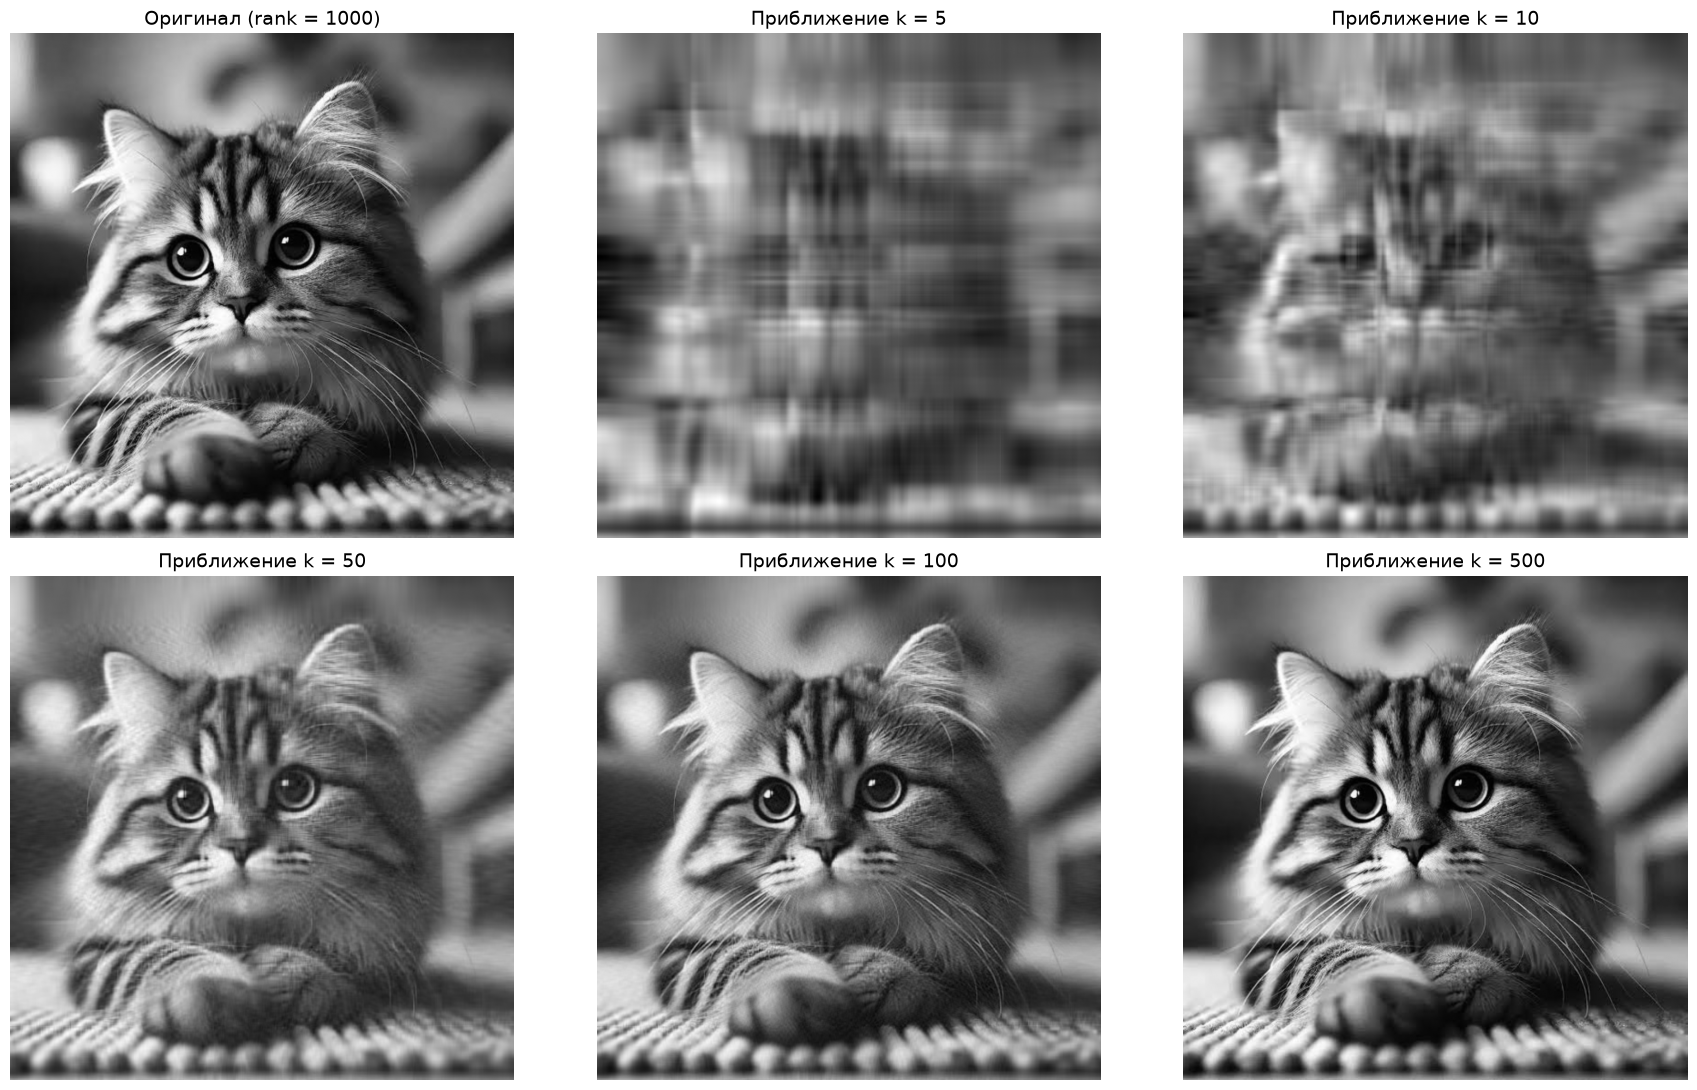

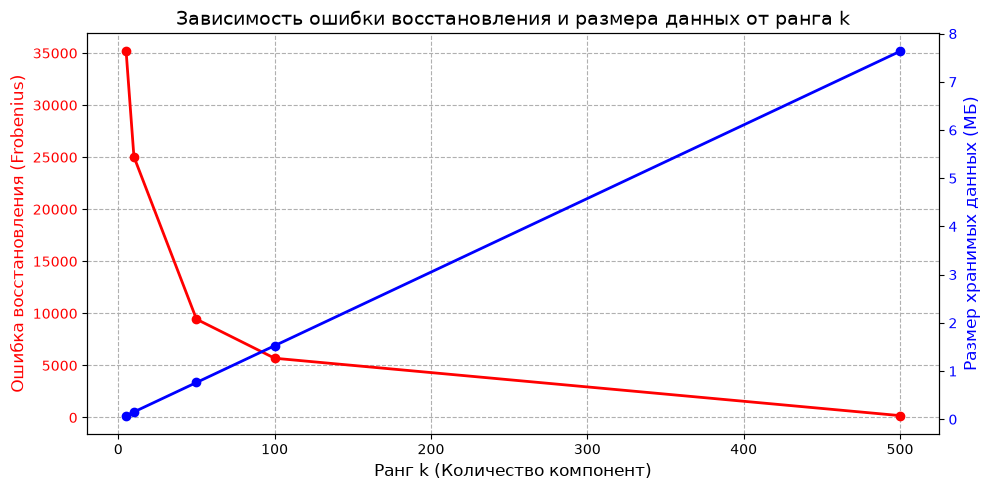

In [8]:
from PIL import Image
import matplotlib.pyplot as plt


img = Image.open("photo_1000_1000.jpg").convert("L")
img_vec = np.array(img, dtype=float)

k_values = [5, 10, 50, 100, 500]
compressed_images = {}
errors = []
sizes_bytes = []

original_size_mb = (img_vec.nbytes) / (1024 * 1024)

U, S, Vt = np.linalg.svd(img_vec, full_matrices=False)

for k in k_values:
    img_k = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    compressed_images[k] = img_k

    # Расчет ошибки восстановления 
    # (Норма Фробениуса разности между оригиналом и сжатием)
    # 'fro' - Норма Фробениуса
    error = np.linalg.norm(img_vec - img_k, 'fro')
    errors.append(error)

    # Расчет размера данных. Вместо 1000x1000 мы храним:
    # U[:, :k] -> 1000*k, S[:k] -> k, Vt[:k, :] -> k*1000 чисел. 
    # Каждое float64 число весит 8 байт.
    elements_count = 1000 * k + k + k * 1000
    size_mb = (elements_count * 8) / (1024 * 1024)
    sizes_bytes.append(size_mb)


# Картинки (оригинальная и сжатая)
plt.figure(figsize=(18, 11))

plt.subplot(2, 3, 1)
plt.title("Оригинал (rank = 1000)", fontsize=14)
plt.imshow(img_vec, cmap="gray")
plt.axis("off")

for i, k in enumerate(k_values, start=2):
    plt.subplot(2, 3, i)
    plt.title(f"Приближение k = {k}", fontsize=14)
    plt.imshow(compressed_images[k], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Графики ошибок
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Ранг k (Количество компонент)', fontsize=12)
ax1.set_ylabel('Ошибка восстановления (Frobenius)', color="red", fontsize=12)
ax1.plot(k_values, errors, marker='o', color="red", linewidth=2)
ax1.tick_params(axis='y', labelcolor="red")
ax1.grid(True, linestyle='--')

ax2 = ax1.twinx()
ax2.set_ylabel('Размер хранимых данных (МБ)', color="blue", fontsize=12)
ax2.plot(k_values, sizes_bytes, marker='o', color="blue", linewidth=2)
ax2.tick_params(axis='y', labelcolor="blue")

plt.title('Зависимость ошибки восстановления и размера данных от ранга k', fontsize=14)
fig.tight_layout()
plt.show()


3. **Eigenfaces.** Загрузите датасет LFW (лица). Сделайте PCA с k=50. Визуализируйте первые 16 компонент как «средние лица».


Количество фотографий: 1288,    
Высота изображения: 50,    
Ширина изображения: 37


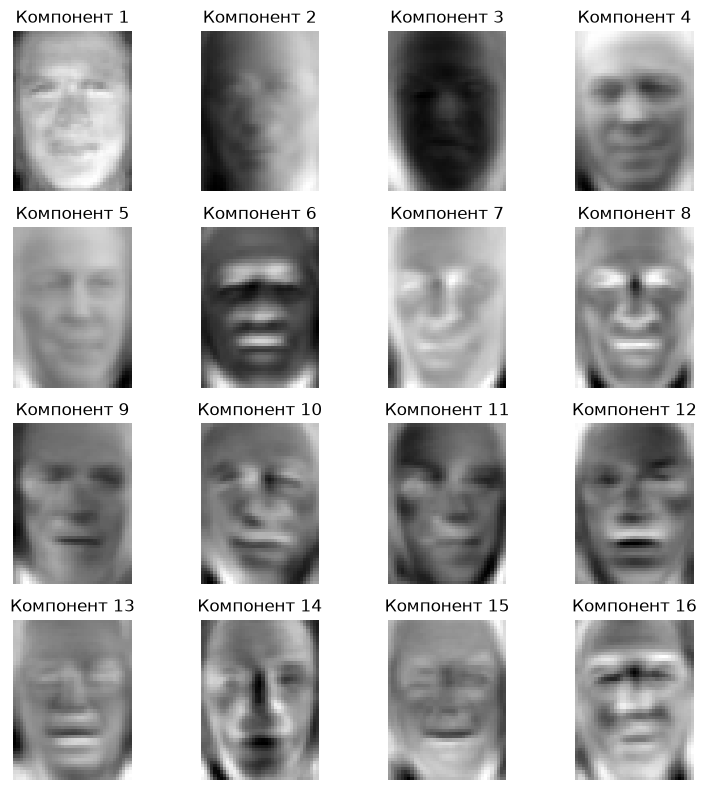

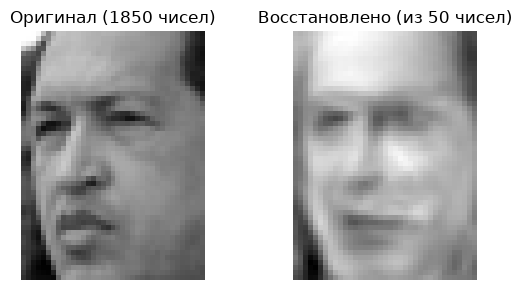

In [9]:
from sklearn.datasets import fetch_lfw_people


def pca(X, k):
    X_centred = X - X.mean(axis=0)
    U, S, Vt = np.linalg.svd(X_centred, full_matrices=False)
    components = Vt[:k, :]
    X_reduced = X_centred @ components.T
    return X_reduced, components


# Выкачиваем датасет (оставляем людей, у которых минимум 70 фото)
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# Сохраняем исходные размеры картинок, чтобы потом сделать обратный reshape
n_samples, h, w = lfw_people.images.shape
print(f"Количество фотографий: {n_samples},\
    \nВысота изображения: {h},\
    \nШирина изображения: {w}")

# X — матрица, где каждая строка — вытянутая в вектор картинка (shape: 1288 x 1850)
X = lfw_people.data
k = 50
X_reduced, components = pca(X, k)

# Отбираем первые 16 главных компонент
eigenfaces = components[:16, :]

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    face_image = eigenfaces[i].reshape(h, w)

    ax.imshow(face_image, cmap="gray")
    ax.set_title(f"Компонент {i + 1}", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()



# --- 1. Подготовка среднего лица и выбор конкретного человека ---
X_mean = X.mean(axis=0)

# Берем первого человека из датасета (индекс 0)
person_index = 0
original_flat = X[person_index]
person_coefficients = X_reduced[person_index]

# --- 2. Магия восстановления (Реконструкция) ---
# Умножаем 50 коэффициентов на 50 шаблонов и возвращаем среднее лицо
reconstructed_flat = (person_coefficients @ components) + X_mean

# --- 3. Решейп в формат картинок (50x37) ---
img_original = original_flat.reshape(h, w)
img_reconstructed = reconstructed_flat.reshape(h, w)

# --- 4. Отрисовка сравнения ---
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Показываем оригинал
axes[0].imshow(img_original, cmap="gray")
axes[0].set_title("Оригинал (1850 чисел)")
axes[0].axis("off")

# Показываем восстановленную копию
axes[1].imshow(img_reconstructed, cmap="gray")
axes[1].set_title("Восстановлено (из 50 чисел)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


# Метод Eigenfaces: Анализ главных компонент (PCA) для распознавания лиц

В компьютерном зрении изображения лиц состоят из тысяч пикселей, которые сильно зависят друг от друга (например, при изменении освещения синхронно меняются сотни точек). Программа решает задачу **снижения размерности**: она находит скрытые геометрические и световые закономерности, позволяя описывать массивные картинки небольшим набором чисел.

---

## Математическая и логическая суть алгоритма по шагам

### 1. Подготовка данных (Решейп в векторы)
В исходном виде датасет представляет собой стопку двумерных изображений. Чтобы применить к ним методы линейной алгебры, каждая фотография размером `Высота × Ширина` (например, $50 \times 37 = 1850$ пикселей) «вытягивается» в одну длинную строчку. 
* На выходе формируется матрица данных $X$, где каждая **строка** — это отдельный человек, а каждый **столбец** — конкретная координата пикселя.

### 2. Центрирование данных (Сдвиг облака)
Программа вычисляет среднее значение для каждого пикселя по всей базе лиц. Это среднее значение можно представить как **«среднестатистическое лицо»** — размытый серый овал, содержащий базовые шаблоны, общие для всех людей (наличие двух глаз, носа, губ).
* При выполнении операции `X - X.mean(axis=0)` это среднее лицо вычитается из каждого портрета. 
* **Результат**: Мы переносим начало координат многомерного пространства строго в геометрический центр облака данных. В матрице остаются только **индивидуальные отклонения** конкретного человека от стандарта (например, «нос шире среднего», «тень падает слева»).

### 3. Разложение SVD (Поиск главных осей)
Сингулярное разложение (`np.linalg.svd`) анализирует связи между пикселями и находит направления в многомерном пространстве, вдоль которых данные имеют максимальный разброс (дисперсию). Результатом является матрица $V^T$ (`Vt`), где строки отсортированы по важности:
* **Первая главная компонента** (строка 0) отражает самое сильное и масштабное изменение во всем датасете (обычно это глобальное направление освещения).
* **Каждая последующая компонента** отвечает за все более тонкие анатомические особенности (форма челюсти, разрез глаз, наличие улыбки, очков или усов).
* **Последние компоненты** содержат случайный цифровой шум и мелкие дефекты съемки, не несущие важного смысла.

### 4. Срез `components = Vt[:k]` и Сжатие (Проекция)
Мы принудительно ограничиваем модель, забирая только первые $k=50$ строк матрицы $V^T$. Этим шагом мы отбрасываем весь шум и заявляем, что 50 главных типов изменений достаточно для описания структуры любого человеческого лица.
* При перемножении матриц (`@ components.T`) исходное лицо из 1850 пикселей проецируется на эти 50 направлений.
* На выходе получается сжатый вектор всего из **50 чисел**. Это «рецепт» сборки: коэффициенты, показывающие, с какой «громкостью» нужно смешать базовые шаблоны, чтобы восстановить портрет данного человека. Данные сжимаются почти в 37 раз.

### 5. Визуализация «Собственных лиц» (Eigenfaces)
Строки матрицы компонентов являются абстрактными математическими векторами. Чтобы человек мог их оценить, программа отбирает первые 16 векторов и выполняет для них **обратный решейп** в исходный размер фотографии ($50 \times 37$).
* Отрисованная сетка графиков 4x4 демонстрирует **Eigenfaces (собственные лица)**. Они выглядят как призраки, потому что это не реальные люди, а чистые геометрические и световые паттерны, из комбинации которых алгоритм теперь способен воссоздать любое лицо или мгновенно распознать человека.


---
# Восстановление (Реконструкция) лица из сжатых признаков

Восстановление изображения — это процесс, обратный методу главных компонент (PCA). Обладая матрицей из 50 «лиц-призраков» (`components`) и 50 числами-коэффициентами конкретного человека (`X_reduced[i]`), мы можем воссоздать его портрет.

---

## Суть процесса восстановления

Процесс реконструкции выполняется по следующей математической логике:
$$ [\text{Восстановленное лицо} = \text{Среднее лицо} + (\text{Коэффициенты} \times \text{Лица-призраки})] $$

1. **Взвешенное суммирование**: Каждое «лицо-призрак» (строка из матрицы `components`) умножается на соответствующее число-коэффициент человека. Полученные 50 изображений складываются между собой пиксель к пикселю.
2. **Возврат базовых черт**: К результату прибавляется «среднее лицо» (`X.mean(axis=0)`). Это возвращает картинке общие для всех людей анатомические пропорции, которые мы удалили при центрировании.
3. **Обратный решейп**: Итоговый плоский вектор из 1850 чисел перегруппировывается обратно в двумерную матрицу размера 50 × 37 пикселей для отрисовки на экране через `plt.imshow`.

---

> **Важная особенность результата:** Восстановленная картинка получается слегка сглаженной или размытой. Это связано с тем, что мы выбросили компоненты с 51-й по 1850-ю, содержащие мелкий цифровой шум и поры кожи. Однако ключевые геометрии лица (форма носа, разрез глаз, прическа) восстанавливаются идеально, и человек остается полностью узнаваемым.


---
4. **Степенной метод.** Реализуйте поиск максимального собственного числа итеративно: `v ← Av / ||Av||`. Сравните с `np.linalg.eig`.


In [10]:
np.random.seed(42)

A = np.random.randint(1, 10, size=(3, 3)).astype(float)
v_start = np.random.randint(1, 10, size=(3,)).astype(float)

v = v_start / np.linalg.norm(v_start)

eps = 1e-6
max_iter = 1000

# Итерационный цикл (Степенной метод)
for i in range(max_iter):
    # Запоминаем вектор с предыдущего шага до обновления
    v_old = v.copy()

    # Обновляем вектор по формуле из задания
    v = (A @ v) / np.linalg.norm(A @ v)

    # Проверяем сходимость: векторы могут быть сонаправлены (v - v_old)
    # ИЛИ противонаправлены (v + v_old), если ось развернулась на 180°
    if np.linalg.norm(v - v_old) < eps or np.linalg.norm(v + v_old) < eps:
        print(f"Алгоритм сошелся досрочно на итерации №{i}")
        break

# Расчет финального собственного числа через отношение Рэлея
lambda_max = (v @ A @ v) / (v @ v)

eigvals, eigvecs = np.linalg.eig(A)
lambda_max_np = np.max(eigvals)

print(f"Степенной метод (наш код): {lambda_max:.6f}")
print(f"Функция np.linalg.eig:     {lambda_max_np.real:.6f}")
print(f"Результаты совпадают?      {np.allclose(lambda_max_np, lambda_max)}")


Алгоритм сошелся досрочно на итерации №6
Степенной метод (наш код): 17.904501
Функция np.linalg.eig:     17.904501
Результаты совпадают?      True


# Нахождение максимального собственного числа: Степенной метод и отношение Рэлея

В линейной алгебре собственные числа и векторы матрицы удовлетворяют уравнению:
$$A v = \lambda v$$

**Степенной метод (Power Iteration)** — это итерационный численный алгоритм, который позволяет найти **максимальное по модулю** собственное число $\lambda_{max}$ и соответствующий ему собственный вектор без решения сложных характеристических многочленов.

---

## 1. Идея решения задачи («Эффект гравитации»)

Геометрически умножение матрицы на вектор ($A v$) поворачивает и растягивает этот вектор. Если мы возьмем случайный начальный вектор $v$ и начнем циклически умножать его на матрицу $A$ раз за разом, вектор начнет разворачиваться в сторону оси **самого сильного собственного вектора**. Матрица работает как «гравитация», притягивая направление вектора к главной оси.

Чтобы вектор при многократном умножении не улетел в бесконечность и не переполнил память компьютера, на каждом шаге цикла его принудительно **нормализуют** — делят на его собственную евклидову длину (`np.linalg.norm`), сохраняя длину равной $1$.

---

## 2. Логика итерационного цикла

Внутри цикла на каждом шаге происходят следующие действия:
1. **Запоминание прошлого**: `v_old = v.copy()` — сохраняем вектор предыдущего шага.
2. **Обновление**: `v = (A @ v) / np.linalg.norm(A @ v)` — поворачиваем вектор и возвращаем ему единичную длину.
3. **Проверка сходимости**: Вычисляется расстояние между текущим и прошлым шагом через `np.linalg.norm(v - v_old)`. Как только разница становится меньше заданной точности `eps`, это значит, что вектор застыл на главной оси — цикл прерывается.
   * *Защита знака*: Проверка `np.linalg.norm(v + v_old) < eps` необходима на случай, если вектор встал на нужную ось, но развернулся на 180° (сменил знаки на минус).

---

## 3. Откуда берется Формула Рэлея?

После завершения цикла мы получаем направление (вектор $v$), но нам нужно узнать силу растяжения вдоль этой оси — число $\lambda$. Чтобы выразить $\lambda$ из уравнения $Av = \lambda v$, обе части скалярно умножаются слева на $v^T$:

1. $v^T A v = v^T (\lambda v)$
2. Поскольку $\lambda$ — это скаляр, выносим его: $v^T A v = \lambda (v^T v)$
3. Делим на $(v^T v)$ и получаем **отношение Рэлея**:
$$\lambda_{max} = \frac{v^T A v}{v^T v}$$

 В синтаксисе NumPy для одномерных массивов (shape `(N,)`) оператор `@` сам подстраивает форму вектора (как строку слева и как столбец справа) благодаря свойству ассоциативности, поэтому формула не требует явного `.T` и пишется как:
`lambda_max = (v @ A @ v) / (v @ v)`

> **Важный плюс формулы:** Отношение Рэлея работает как математическое усреднение. Даже если вектор $v$ найден с небольшой погрешностью `eps`, ошибки в числителе и знаменателе взаимно компенсируются, выдавая собственное число $\lambda$ с квадратично более высокой точностью.


---
5. **Рекомендации через SVD.** Возьмите матрицу user × movie с пропусками (MovieLens). Сделайте SVD на заполненной нулями версии, выберите k=20. Заполните пропуски как `U Σ V^T`. Посчитайте MAE на тестовой выборке.


In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

np.random.seed(42)
users = np.random.randint(1, 101, size=1000)
movies = np.random.randint(1, 51, size=1000)
ratings = np.random.randint(1, 6, size=1000)

df = pd.DataFrame({"user_id": users, "item_id": movies, "rating": ratings})
# Удаляем дубликаты пар пользователь-фильм, если они появились
df = df.drop_duplicates(subset=["user_id", "item_id"])

R = df.pivot(index="user_id", columns="item_id", values="rating")
train_df, test_df = train_test_split(df, test_size=30, random_state=42)
R_train = train_df.pivot(index="user_id", columns="item_id", values="rating")

# Выравниваем размеры, чтобы учесть всех пользователей и фильмы
R_train_nan = R_train.reindex(index=R.index, columns=R.columns)
R_train_zero = R_train_nan.fillna(0).to_numpy()
print(f"Формат тренировочной матрицы: {R_train_zero.shape}")
print(f"Количество нулей в матрице: {np.sum(R_train_zero == 0)}")

U, S, Vt = np.linalg.svd(R_train_zero, full_matrices=False)
k = 20
R_k = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
print(f"Матрица прогнозов R_pred успешно создана. Размер: {R_k.shape}")

actual_test =[]
pred_test = []

for row in test_df.itertuples():
    u_idx = R.index.get_loc(row.user_id)
    i_idx = R.columns.get_loc(row.item_id)

    actual_test.append(row.rating)
    pred_test.append(R_k[u_idx, i_idx])

mae = np.mean(np.abs(np.array(actual_test) - np.array(pred_test)))
print(mae)



Формат тренировочной матрицы: (100, 50)
Количество нулей в матрице: 4128
Матрица прогнозов R_pred успешно создана. Размер: (100, 50)
2.9276050300833223


SVD на заполненной нулями матрице выдает большую ошибку по двум главным причинам:

## 1. Алгоритм считает нули реальными оценками
SVD не знает, что нули — это просто пропуски. Математически он пытается приблизить всю матрицу разом. Для алгоритма «пропуск» и «оценка 0» — это одно и то же. Так как нулей в матрице больше 80%, SVD подстраивается под них и утягивает все ваши прогнозы вниз, ближе к нулю. В итоге вместо заслуженной «четверки» или «пятерки» модель может предсказать фильму оценку `0.3` или `0.8`.

## 2. Масштаб шкалы оценок
Реальные оценки в тесте лежат в диапазоне от 1 до 5. Если модель из-за засилья нулей предсказывает значения около 0, то абсолютная ошибка $|Actual - Predicted|$ для каждой тестовой строки получается огромной:

* Для оценки 5: $|5 - 0.5| = 4.5$
* Для оценки 4: $|4 - 0.4| = 3.6$

В среднем по всем 30 тестовым фильмам эта ошибка и дает итоговый MAE почти в 3 балла.

---

## Как это легко исправить?
Самый простой способ улучшить результат — перед запуском SVD заполнить пропущенные ячейки не нулями, а средней оценкой по всему датасету (она обычно в районе 3.5). В таком случае алгоритм не будет занижать прогнозы.

Хотите посмотреть, насколько сильно упадет ошибка MAE, если заменить `fillna(0)` на замену средним значением? Написать код для ограничения прогнозов функцией `np.clip(R_k, 1, 5)`, чтобы убрать противоестественные значения?


# Что такое SVD и зачем оно нужно?

**SVD (Singular Value Decomposition)** — это математический инструмент, который разделяет любую матрицу на три составляющие, чтобы найти в данных скрытые взаимосвязи. В рекомендательных системах оно нужно, чтобы превратить хаотичные оценки пользователей в понятные скрытые характеристики.

---

## Зачем нужно SVD?

* **Сжатие данных:** Модель отбрасывает случайный шум и оставляет только важные закономерности.
* **Поиск скрытых смыслов (латентных факторов):** SVD понимает, что если пользователю нравятся *«Интерстеллар»* и *«Марсианин»*, то ему близок скрытый фактор **«космическая фантастика»**.
* **Прогнозирование:** Алгоритм заполняет пустые ячейки в таблице, предсказывая, какую оценку поставил бы пользователь.

---

## Из чего состоит SVD?

Формула раскладывает исходную матрицу рейтингов $R$ на три составляющие:

$$R = U \times \Sigma \times V^T$$

1. **Матрица $U$ (Пользователи $\times$ Факторы):** Показывает, насколько каждый пользователь чувствителен к определенному скрытому фактору (например, насколько сильно он любит драмы).
2. **Матрица $\Sigma$ (Сила факторов):** Диагональная матрица, которая ранжирует скрытые факторы по важности. Самые весомые (например, «боевик» или «комедия») идут первыми.
3. **Матрица $V^T$ (Факторы $\times$ Фильмы):** Показывает, насколько каждый фильм соответствует этим скрытым факторам (например, сколько драмы в конкретном фильме).

Когда мы выбираем параметр $k=20$, мы оставляем только 20 самых сильных факторов из матрицы $\Sigma$, отбрасывая всё остальное как шум.

---

## Математическая суть: Почему алгоритм «подстраивается» под нули?

Классический алгоритм SVD — это чистая линейная алгебра. У него нет «ожиданий», но есть строгий критерий оптимизации: он минимизирует общую ошибку восстановления (**норму Фробениуса**):

$$\min \|R_{train} - \hat{R}\|_F^2 = \min \sum_{u} \sum_{i} (R_{ui} - \hat{R}_{ui})^2$$

### Две причины высокой ошибки (MAE) при заполнении нулями:
1. **Нулей слишком много:** Когда пропуски заменяются на `0.0`, они составляют более 80% матрицы. Алгоритму математически выгоднее занизить все предсказания к нулю, чтобы минимизировать общую ошибку по всей таблице.
2. **Смещение осей:** Вместо поиска реальных жанров, первые латентные факторы начинают кодировать структуру пропусков (перепад между «оценено» и «не оценено»).


---
6. **LSA на текстах.** Постройте TF-IDF матрицу для 100 коротких документов. Сделайте SVD, оставьте 10 компонент. Найдите близкие документы в этом пространстве.


In [12]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

# 1. Загружаем ровно 100 документов из двух контрастных тем
categories = ['sci.space', 'comp.graphics']
newsgroups = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
documents = newsgroups.data[:100] # Берем первые 100 документов

# 2. Строим TF-IDF матрицу (убираем английские стоп-слова)
vectorizer = TfidfVectorizer(stop_words="english", max_features=500)
X_tfidf = vectorizer.fit_transform(documents)

# 3. Делаем SVD (LSA) силами библиотеки scikit-learn и оставляем 10 компонент
svd = TruncatedSVD(n_components=10, random_state=42)
X_lsa = svd.fit_transform(X_tfidf)
print(f"Размер исходной TF-IDF матрицы: {X_tfidf.shape}")  # 100 документов на 500 слов
print(f"Размер сжатой матрицы после SVD (LSA): {X_lsa.shape}")  # 100 документов на 10 признаков

# 4. Вычисляем матрицу схожести между всеми 100 документами (размер 100x100)
similarity_matrix = cosine_similarity(X_lsa)
print(similarity_matrix.shape)
doc_idx = 0
print(documents[doc_idx][:200] + "...")
print("\n=============")
# Находим индекс самого похожего на него документа (не считая его самого)
scores = similarity_matrix[doc_idx]
most_similar_doc_idx = scores.argsort()[-2]
print(documents[most_similar_doc_idx][:200] + "...")

Размер исходной TF-IDF матрицы: (100, 500)
Размер сжатой матрицы после SVD (LSA): (100, 10)
(100, 100)

I usually use "Algorithms for graphics and image processing" by
Theodosios Pavlidis, but other people here got them same idea and now
3 of 4 copies in the libraries have been stolen!

Another referen...


This sounds wonderful, but it seems no one either wants to spend time doing
this, or they don't have the power to do so.  For example, I would like
to see a comp.graphics architecture like this:

com...


# Латентно-семантический анализ (LSA)

**LSA (Latent Semantic Analysis)** — это метод обработки естественного языка (NLP), который находит скрытые (латентные) смысловые связи между словами и документами. 

В основе LSA лежит идея о том, что слова, используемые в схожих контекстах, имеют близкое значение.

---

## Как устроен LSA математически?

Алгоритм преобразует текст в абстрактное пространство тем за три шага:

1. **Построение матрицы (Документы × Слова):** Тексты переводятся в числа с помощью метрики **TF-IDF**. Строки матрицы — это документы, а столбцы — отдельные слова.
2. **Сингулярное разложение (SVD):** Исходная разреженная матрица раскладывается на три составляющие, выявляя скрытые концепты (темы).
3. **Снижение размерности ($k$):** Мы оставляем только $k$ самых важных тем (например, $k=10$), отбрасывая мелкие детали, редкие слова и опечатки как случайный шум.

---

## Какие проблемы решает LSA?

* **Синонимия (разные слова — один смысл):** Алгоритм поймет, что документы со словами *«автомобиль»* и *«машина»* похожи по смыслу, даже если у них нет других общих слов.
* **Полисемия (одно слово — разные смыслы):** Метод способен разграничить слово *«ключ»* (родник) и *«ключ»* (от замка) благодаря анализу окружающего контекста.
* **Сжатие данных:** Вместо работы с огромным словарем в десятки тысяч слов, тексты сравниваются в компактном и плотном пространстве из нескольких десятков тем.


# Какую роль выполняет SVD в текстовом анализе?

В алгоритме LSA сингулярное разложение (SVD) выполняет роль **«сжимателя» и «переводчика»** с языка отдельных ключевых слов на язык скрытых абстрактных тем.

---

## Что конкретно делает SVD с текстом:

### 1. Объединяет похожие слова в концепты (темы)
Исходная матрица TF-IDF слишком громоздкая: в ней может быть 500 и более столбцов-слов. SVD находит слова, которые почти всегда используются в связке друг с другом (например, *«space»*, *«orbit»*, *«satellite»*), и математически «склеивает» их в один абстрактный фактор — **«Тема №1»** (Космос). Слова *«pixels»*, *«screen»*, *«rendering»* он объединяет в **«Тему №2»** (Графика).

### 2. Переписывает описание документов через темы
Вместо того чтобы хранить информацию в виде: *«В документе №5 есть слово "спутник" с весом 0.4 и слово "орбита" с весом 0.5»*, SVD пересчитывает координаты и записывает гораздо лаконичнее: *«Документ №5 на 90% состоит из Темы №1 (Космос) и на 0% из Темы №2 (Графика)»*. 

### 3. Очищает текст от случайного шума
Когда вы указываете параметр `n_components=10`, SVD оставляет только 10 самых мощных, глобальных тем во всем корпусе текстов. Если в серьезном письме про космос случайно промелькнуло одиночное слово *«яблоко»*, алгоритм просто проигнорирует его при разложении, так как оно не укладывается ни в один из 10 главных векторов дисперсии.

---

## Итог:
SVD сжимает матрицу из пространства слов (**100 × 500**) в пространство смыслов (**100 × 10**). Сравнивать документы по 10 емким латентным темам математически надежнее и точнее, чем искать буквальные совпадения по 500 разрозненным словам.


# Почему алгоритм находит 10 тем, если исходных категорий всего две?

Концептуально в выбранных текстах заложены всего **две глобальные супер-темы** — «Космос» (`sci.space`) и «Графика» (`comp.graphics`). 

Однако алгоритм SVD ничего не знает про наши ярлыки категорий. Он смотрит исключительно на математическую структуру матрицы слов и дробит эти две большие темы на более мелкие смысловые подтемы (нюансы контекста) по нескольким причинам:

---

## Как именно SVD распределяет 10 компонентов:

### 1. Дробление больших категорий на внутренние подтемы
Каждая из двух тем внутри устроена неоднородно. SVD улавливает эти смысловые развилки и выделяет их в отдельные скрытые факторы:
* **Категория «Космос»** дробится на:
  * *Подтему марсианских миссий* (слова: *Марс, ровер, миссия, грунт*).
  * *Подтему орбитальной техники* (слова: *спутник, запуск, ракета, траектория*).
  * *Подтему глубокого космоса* (слова: *телескоп, Хаббл, галактика, черная дыра*).
* **Категория «Графика»** дробится на:
  * *Аппаратную подтему* (слова: *видеокарта, драйвер, монитор, VGA*).
  * *Алгоритмическую подтему* (слова: *рендеринг, полигоны, трассировка лучей, 3D*).

### 2. Выделение специфических речевых паттернов
Некоторые скрытые компоненты SVD тратит на кодирование устойчивых стилистических оборотов, характерных для интернет-форумов. Слова вроде *«проблема», «помогите», «ошибка», «спасибо», «версия»* часто встречаются в связке. Для математики алгоритма это такой же устойчивый паттерн, как и тематический синонимичный ряд.

### 3. Информационный «хвост» (избыточность)
Матрица сингулярных чисел $\Sigma$ ранжирует компоненты строго по их важности (вкладу в дисперсию):
* Первые **2–3 темы** забирают на себя основной объем полезной информации и наглядно разделяют Космос и Графику.
* Компоненты **с 4-й по 10-ю** являются более слабыми. Они кодируют мелкие, локальные совпадения слов, которые содержатся лишь в нескольких документах из ста.


---
7. **Условное число.** Посчитайте `s[0] / s[-1]` для матриц с разной обусловленностью. Покажите, как растёт ошибка при решении плохо обусловленных систем.


In [ ]:
import numpy as np

# Фиксируем случайность
np.random.seed(42)

# ==========================================
# 1. ХОРОШО ОБУСЛОВЛЕННАЯ СИСТЕМА (СТАБИЛЬНАЯ)
# ==========================================
# Строки матрицы ортогональны
A_good = np.array([[-1.0, 2.0],
                   [2.0, 1.0]])

# Истинный вектор b и вектор с крошечной ошибкой (шумом)
b_true = np.array([5.0, 4.0])
b_noisy = np.array([5.0, 4.001]) # добавили всего 0.001

# Делаем SVD, чтобы посчитать число обусловленности
_, s_good, _ = np.linalg.svd(A_good)
cond_good = s_good[0] / s_good[-1]

# Решаем систему Ax = b для обоих случаев
x_good_true = np.linalg.solve(A_good, b_true)
x_good_noisy = np.linalg.solve(A_good, b_noisy)
error_good = np.linalg.norm(x_good_true - x_good_noisy)

# ==========================================
# 2. ПЛОХО ОБУСЛОВЛЕННАЯ СИСТЕМА (НЕСТАБИЛЬНАЯ)
# ==========================================
# Строки матрицы почти параллельны (вторая строка почти дублирует первую)
A_bad = np.array([[1.0, 2.0],
                  [1.0, 2.00001]])

# Решаем эту систему с теми же b_true и b_noisy
_, s_bad, _ = np.linalg.svd(A_bad)
cond_bad = s_bad[0] / s_bad[-1]

x_bad_true = np.linalg.solve(A_bad, b_true)
x_bad_noisy = np.linalg.solve(A_bad, b_noisy)
error_bad = np.linalg.norm(x_bad_true - x_bad_noisy)


print("=== СТАБИЛЬНАЯ СИСТЕМА ===")
print(f"Число обусловленности (s[0]/s[-1]): {cond_good:.2f}")
print(f"Истинный ответ x: {x_good_true}")
print(f"Искаженный ответ x: {x_good_noisy}")
print(f"Итоговый сдвиг ответа (ошибка): {error_good:.6f}\n")

print("=== НЕСТАБИЛЬНАЯ СИСТЕМА ===")
print(f"Число обусловленности (s[0]/s[-1]): {cond_bad:.2f} (ОГРОМНОЕ!)")
print(f"Истинный ответ x: {x_bad_true}")
print(f"Искаженный ответ x: {x_bad_noisy}")
print(f"Итоговый сдвиг ответа (ошибка): {error_bad:.6f} <-- Ошибка взлетела в 100 000 раз!")


=== СТАБИЛЬНАЯ СИСТЕМА ===
Число обусловленности (s[0]/s[-1]): 1.00
Истинный ответ x: [0.6 2.8]
Искаженный ответ x: [0.6004 2.8002]
Итоговый сдвиг ответа (ошибка): 0.000447

=== НЕСТАБИЛЬНАЯ СИСТЕМА ===
Число обусловленности (s[0]/s[-1]): 1000004.00 (ОГРОМНОЕ!)
Истинный ответ x: [200004.99999869 -99999.99999934]
Искаженный ответ x: [199804.99999869 -99899.99999935]
Итоговый сдвиг ответа (ошибка): 223.606798 <-- Ошибка взлетела в 100 000 раз!


# Обусловленность матриц и методы её определения

**Обусловленность матрицы** — это мера чувствительности системы линейных уравнений к малым погрешностям во входных данных (правой части или коэффициентах самой матрицы). 

Простыми словами: она показывает, насколько сильно изменятся ответы ($x$), если мы совсем немного изменим начальные условия ($b$) в уравнении $Ax = b$.

---

## Как определить обусловленность

Для определения этого свойства используют **число обусловленности** (обозначается как $\kappa(A)$ или $\text{cond}(A)$).

### 1. Основная формула
Число обусловленности находится как произведение нормы самой матрицы на норму её обратной матрицы:

$$\kappa(A) = \|A\| \cdot \|A^{-1}\|$$

*Если матрица вырожденная (определитель равен 0), её число обусловленности стремится к бесконечности ($\infty$).*

### 2. Через собственные или сингулярные значения
Для разных типов матриц (при использовании евклидовой нормы $\|\cdot\|_2$) число обусловленности можно найти быстрее:

* **Для симметричных матриц:** Отношение максимального по модулю собственного значения к минимальному.
  $$\kappa(A) = \frac{|\lambda_{\max}|}{|\lambda_{\min}|}$$
* **Для любых квадратных матриц:** Отношение максимального сингулярного значения к минимальному (через SVD-разложение).
  $$\kappa(A) = \frac{\sigma_{\max}}{\sigma_{\min}}$$

---

## Как интерпретировать результат

Число обусловленности всегда **больше или равно 1** ($\kappa(A) \ge 1$).

* **$\kappa(A) \approx 1$ (Хорошо обусловленная матрица):** Малые погрешности на входе дают малые погрешности на выходе. Решение стабильно. Идеальный пример — единичная матрица ($\kappa(I) = 1$).
* **$\kappa(A) \gg 1$ (Плохо обусловленная матрица):** Даже микроскопическая ошибка в округлении чисел или измерении приведет к колоссальным искажениям в ответе. Компьютерные методы могут выдать абсолютно неверный результат.

> **Правило большого пальца:** Если $\kappa(A) = 10^k$, то при решении системы на компьютере вы можете потерять до $k$ значащих цифр точности из-за ошибок округления.

---

## Пример «на пальцах»

Представим систему уравнений, где прямые на графике почти параллельны:

**Исходная система:**
1. $x + y = 2$
2. $x + 1.001y = 2.001$  
*Точное решение: $x = 1, y = 1$.*

**Система с минимальным шумом** (изменим правую часть второго уравнения всего на $0.001$):
1. $x + y = 2$
2. $x + 1.001y = 2.002$  
*Новое решение: $x = 0, y = 2$.*

Входные данные изменились на сотые доли процента, а ответ изменился кардинально (на 100%). Матрица этой системы имеет очень большое число обусловленности.


# Геометрический смысл: направление строк матрицы

Направление строк в матрице (а именно **угол между векторами-строками**) напрямую определяет её обусловленность. Это самый наглядный способ понять, почему матрица становится «плохой».

> **Главное правило:** Чем ближе векторы-строки к тому, чтобы быть параллельными друг другу, тем хуже обусловлена матрица.

---

## Три сценария направления строк

Если представить каждую строку квадратной матрицы размера $n \times n$ как вектор в $n$-мерном пространстве, возможны три крайних случая:

1. **Ортогональные строки (угол $\theta = 90^\circ$):**
   * Векторы смотрят в абсолютно разных направлениях.
   * **Результат:** Идеальная обусловленность ($\kappa(A) \approx 1$). Матрица максимально устойчива к ошибкам вычислений.
2. **Почти коллинеарные строки (угол $\theta \approx 0^\circ$ или $180^\circ$):**
   * Векторы направлены почти в одну сторону. Это значит, что строки дублируют информацию друг друга с минимальными различиями.
   * **Результат:** Плохая обусловленность ($\kappa(A) \gg 1$). Система становится гиперчувствительной к шуму.
3. **Параллельные строки (угол $\theta = 0^\circ$ или $180^\circ$):**
   * Векторы линейно зависимы.
   * **Результат:** Число обусловленности равно бесконечности ($\kappa(A) = \infty$). Матрица вырождена ($\det(A) = 0$), система не имеет единственного решения.

---

## Что это означает на графике

В системе линейных уравнений $Ax = b$ каждая строка задает геометрическую плоскость (в 2D — прямую линию). Решение системы — это точка пересечения этих линий.

* **Строки перпендикулярны:** Прямые пересекаются жестко крест-накрест. Если слегка сдвинуть одну из линий (внести погрешность), точка пересечения сместится ровно на такую же микроскопическую величину.
* **Строки почти параллельны:** Прямые идут рядом друг с другом, практически сливаясь. Если сдвинуть одну из линий на микрон, точка их пересечения «улетит» далеко в сторону.

---

## Математический расчет углов между строками

Чтобы численно оценить, насколько направления строк близки к параллельности, вычисляют косинус угла между ними через скалярное произведение.

Для двух строк-векторов $r_i$ и $r_j$:

$$\cos(\theta) = \frac{r_i \cdot r_j}{\|r_i\| \cdot \|r_j\|}$$

* Если $|\cos(\theta)| \approx 0$, то строки близки к перпендикулярности (хороший знак).
* Если $|\cos(\theta)| \approx 1$, то строки почти параллельны (признак плохой обусловленности).


---
8. **Truncated SVD vs PCA.** Сравните `sklearn.TruncatedSVD` и `sklearn.PCA` на разреженной матрице. В чём отличие?


# Разреженные матрицы (Sparse Matrices)

**Разреженная матрица** — это матрица, в которой **подавляющее большинство элементов равны нулю**. 

Если нулевых элементов в матрице очень много (обычно более 80–90%), хранить и обрабатывать её в памяти компьютера как обычную «плотную» таблицу (Dense matrix) становится крайне неэффективно.

---

## В чем проблема обычного хранения?

Представьте матрицу размера $100\,000 \times 100\,000$, в которой в каждой строке содержится всего по 2–3 ненулевых значения:
* **Обычный подход (Dense):** Компьютер выделяет память под все 10 миллиардов ячеек. Это займет около 80 Гигабайт оперативной памяти, при этом 99.9% места будет занято абсолютно бесполезными нулями.
* **Разреженный подход (Sparse):** Компьютер запоминает **только** координаты (индекс строки и столбца) и значения тех элементов, которые не равны нулю. Такая матрица займет всего несколько Мегабайт и поместится на любом устройстве.

---

## Основные форматы хранения разреженных матриц

Чтобы эффективно использовать память и процессорное время, в программировании (например, в библиотеке `scipy.sparse`) используют специальные форматы:

1. **COO (Coordinate Format — формат координат)**
   * Хранит три простых массива: `[индекс строки]`, `[индекс столбца]`, `[значение]`.
   * *Плюсы:* Идеален для быстрого создания и наполнения матрицы с нуля.
2. **CSR (Compressed Sparse Row — сжатая строка)**
   * Сложная структура, которая сжимает информацию об индексах строк, оптимизируя доступ к ним.
   * *Плюсы:* Самый популярный формат для проведения быстрых математических операций (например, умножения матрицы на вектор).
3. **CSC (Compressed Sparse Column — сжатый столбец)**
   * Аналог CSR, но сжатие происходит по столбцам, а не по строкам.
   * *Плюсы:* Оптимален для быстрого извлечения вертикальных срезов (столбцов) матрицы.

---

## Где это применяется на практике?

* **Графы и социальные сети:** Матрица смежности пользователей в соцсетях. Заголовки строк и столбцов — это миллионы людей, но каждый конкретный человек дружит лишь с сотыми долями процента от общего числа пользователей.
* **Анализ текста (NLP):** Матрица «документ-слово» (Bag of Words / TF-IDF). Строки — это статьи, столбцы — все уникальные слова из языка. В рамках одной статьи используется лишь крошечная часть глобального словаря.
* **Физические симуляции:** Решение систем дифференциальных уравнений (метод конечных элементов). Применяется для расчетов прочности мостов, аэродинамики автомобилей или прогнозирования погоды.


---
8. **Truncated SVD vs PCA.** Сравните `sklearn.TruncatedSVD` и `sklearn.PCA` на разреженной матрице. В чём отличие?


In [32]:
from sklearn.decomposition import PCA, TruncatedSVD
from scipy import sparse

np.random.seed(42)

# 1. Создаем разреженную матрицу (например, 1000 документов на 5000 слов, заполнена на 1%)
dense_matrix = np.random.binomial(1, 0.001, size=(1000, 5000)).astype(float)
sparse_matrix = sparse.csr_matrix(dense_matrix)

svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(sparse_matrix)
print("TruncatedSVD успешно выполнил сжатие разреженной матрицы.")
print(X_svd)

try:
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(sparse_matrix)
    print("PCA успешно выполнил сжатие разреженной матрицы.")
    print(X_pca)
except TypeError as e:
    print(f"PCA выдал ошибку: {e}")
    print("Причина: PCA требует плотную матрицу, так как центрирование уничтожает разреженность!")


centered_matrix = dense_matrix - dense_matrix.mean(axis=0)
non_zeros_after_centering = np.count_nonzero(centered_matrix)

print(f"Доля ненулевых элементов после центрирования (как в PCA): {non_zeros_after_centering / (1000*5000) * 100:.2f}%")

TruncatedSVD успешно выполнил сжатие разреженной матрицы.
[[ 0.00167893  0.00090964]
 [ 0.06535007 -0.01241399]
 [ 0.01870941 -0.00454205]
 ...
 [-0.00290029 -0.01078104]
 [ 0.03200548  0.06046909]
 [-0.03618982  0.00499481]]
PCA успешно выполнил сжатие разреженной матрицы.
[[-0.01089465 -0.00218713]
 [ 0.00803501  0.0360015 ]
 [-0.02751165 -0.00396108]
 ...
 [-0.02159653 -0.00831777]
 [-0.03178805 -0.01696502]
 [-0.03633982 -0.00034268]]
Доля ненулевых элементов после центрирования (как в PCA): 62.70%


## Главный вывод эксперимента

Даже с учетом "пустых" столбцов, центрирование увеличило плотность матрицы **в 627 раз** (с 0.1% до 62.7%). 

* **Для PCA** это означает, что ему всё равно пришлось бы обрабатывать и хранить в памяти миллионы сгенерированных чисел вместо нулей.
* **Для TruncatedSVD** эти вычисления не потребовались, так как он проигнорировал пустые пространства и работал напрямую с исходными 0.1% данных.

# Почему для разреженных матриц используют TruncatedSVD вместо PCA?

При работе с разреженными данными (тексты, графы, разреженные бинарные матрицы) вы столкнетесь с фундаментальным различием между методами снижения размерности `PCA` и `TruncatedSVD`.

---

## Главное концептуальное отличие

### 1. PCA (Principal Component Analysis)
* **Как работает:** Перед поиском компонент алгоритм **центрирует данные** (из каждого элемента вычитает среднее значение его столбца).
* **Проблема с разреженностью:** Представьте, что среднее значение столбца равно `0.02`. Если вычесть его из всех нулевых элементов (которых в матрице 99%), они превратятся в `-0.02`. Матрица мгновенно становится **плотной (Dense)**.
* **Что происходит в коде:** Библиотека `scikit-learn` внутри метода `PCA.fit_transform()` не падает с ошибкой, а молниеносно выполняет неявное приведение разреженной матрицы к плотному формату через `.toarray()`. Если матрица гигантская, ваш скрипт рухнет с ошибкой `MemoryError`.

### 2. TruncatedSVD (Truncated Singular Value Decomposition)
* **Как работает:** Выполняет сингулярное разложение матрицы **без предварительного центрирования данных**.
* **Почему это круто:** Алгоритм оперирует исключительно ненулевыми элементами, полностью сохраняя структуру разреженной матрицы (`CSR`/`CSC`) в памяти на протяжении всего процесса вычислений.
* **Применение:** Это стандарт индустрии в обработке естественного языка (NLP), где данный метод часто называют **LSA (Latent Semantic Analysis)**.

---